## Simulación de un sistema mimo

$$
G(s)=\left[\begin{array}{ll}
G_{11}(s) & G_{12}(s) \\
G_{21}(s) & G_{22}(s)
\end{array}\right]
$$

In [4]:
!pip install control

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 578.3/578.3 kB 12.6 MB/s eta 0:00:00


In [5]:
# Para G11
tau_11 = 159.0457
tm_11 = 2.9464
K11 = 0.3271
# G12
tau_12 = 228.7841
tm_12 = 34.1899
K12 = 0.2327

# Para G22
tau_22 = 169.0153
tm_22 = 12.5972
K22 = 0.2931
# G21
tau_21 = 232.3133
tm_21 = 46.9798
K21 = 0.1573


In [6]:
import control as ct

In [7]:
s = ct.TransferFunction.s

G11 = K11/(tau_11*s + 1)
print(G11)
G12 = K12/(tau_12*s + 1)
print(G12)

G22 = K22/(tau_22*s + 1)
print(G22)
G21 = K21/(tau_21*s + 1)
print(G21)

<TransferFunction>: sys[5]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

   0.3271
  ---------
  159 s + 1
<TransferFunction>: sys[11]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

    0.2327
  -----------
  228.8 s + 1
<TransferFunction>: sys[17]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

   0.2931
  ---------
  169 s + 1
<TransferFunction>: sys[23]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

    0.1573
  -----------
  232.3 s + 1


In [8]:
G_mimo = ct.tf([[G11,G12],
                [G21,G22]])
print(G_mimo)

<TransferFunction>: sys[24]
Inputs (2): ['u[0]', 'u[1]']
Outputs (2): ['y[0]', 'y[1]']

Input 1 to output 1:

   0.3271
  ---------
  159 s + 1

Input 1 to output 2:

    0.1573
  -----------
  232.3 s + 1

Input 2 to output 1:

    0.2327
  -----------
  228.8 s + 1

Input 2 to output 2:

   0.2931
  ---------
  169 s + 1


In [9]:
import numpy as np
import matplotlib.pyplot as plt


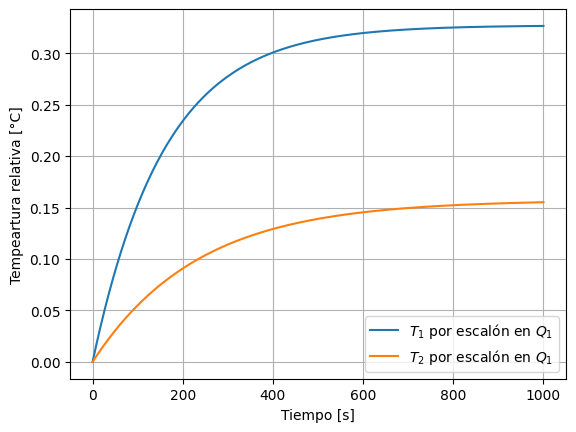

In [10]:
t = np.linspace(0,1000,1000)

t1, y11 = ct.step_response(G11,t)
t1, y21 = ct.step_response(G21,t)

# Caso1: Escalon en Q1 y Q2 = 0
plt.figure()
plt.plot(t1,y11 , label = r"$T_1$ por escalón en $Q_1$")
plt.plot(t1,y21 , label = r"$T_2$ por escalón en $Q_1$")
plt.grid(True)
plt.xlabel("Tiempo [s]")
plt.ylabel("Tempeartura relativa [°C]")
plt.legend()
plt.show()

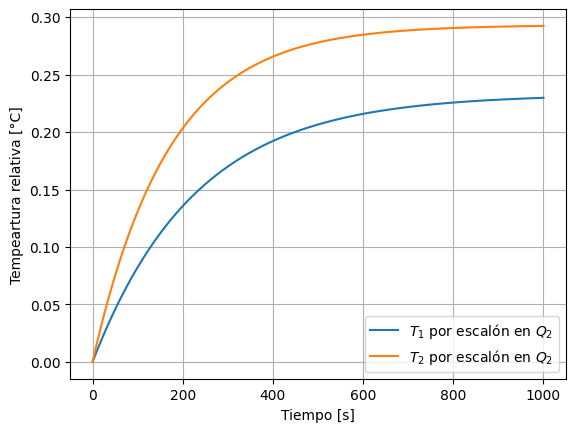

In [11]:
t2, y12 = ct.step_response(G12,t)
t2, y22 = ct.step_response(G22,t)

# Caso1: Escalon en Q2 y Q1 = 0
plt.figure()
plt.plot(t2,y12 , label = r"$T_1$ por escalón en $Q_2$")
plt.plot(t2,y22 , label = r"$T_2$ por escalón en $Q_2$")
plt.grid(True)
plt.xlabel("Tiempo [s]")
plt.ylabel("Tempeartura relativa [°C]")
plt.legend()
plt.show()

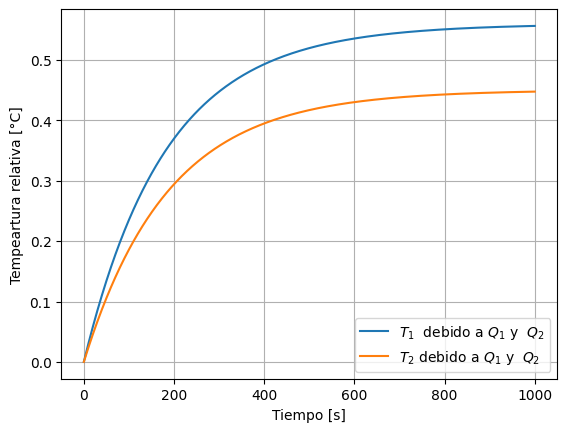

In [12]:
# Ambos calentadores encendidos simultáneamente

# En lazo abierto
T1_total = y11 + y12
T2_total = y21 + y22


plt.figure()
plt.plot(t2,T1_total , label = r"$T_1$  debido a $Q_1$ y  $Q_2$")
plt.plot(t2,T2_total , label = r"$T_2$ debido a $Q_1$ y  $Q_2$")
plt.grid(True)
plt.xlabel("Tiempo [s]")
plt.ylabel("Tempeartura relativa [°C]")
plt.legend()
plt.show()

## **Parte E: Diseño de desacoplador**

### Teoría del Desacoplador

Usando las ganancias estacionarias:

$$
G(0) = \begin{bmatrix}
K_{11} & K_{12} \\
K_{21} & K_{22}
\end{bmatrix}
$$

se desea que:

$$
G(0)D \approx \text{diagonal}
$$

Realizando la multiplicación:

$$
G(0)D = \begin{bmatrix}
K_{11} + K_{12}d_{21} & K_{11}d_{12} + K_{12} \\
K_{21} + K_{22}d_{21} & K_{21}d_{12} + K_{22}
\end{bmatrix}
$$

Para reducir el acoplamiento, se requiere que los elementos fuera de la diagonal sean cero:

$$
K_{11}d_{12} + K_{12} = 0 \quad \Rightarrow \quad d_{12} = -\frac{K_{12}}{K_{11}}
$$

$$
K_{21} + K_{22}d_{21} = 0 \quad \Rightarrow \quad d_{21} = -\frac{K_{21}}{K_{22}}
$$

Finalmente, la matriz desacopladora es:

$$
D = \begin{bmatrix}
1 & -\frac{K_{12}}{K_{11}} \\
-\frac{K_{21}}{K_{22}} & 1
\end{bmatrix}
$$

In [13]:
D = [[1,-K12/K11],
      [-K21, 1]]
D

[[1, -0.7114032405992051], [-0.1573, 1]]

## **Parte F: Diseño pid**

### Teoría del Diseño de Controladores PID

Se requiere diseñar dos controladores PID independientes:

$$
C_1(s) \quad (32)
$$

$$
C_2(s) \quad (33)
$$

de la forma:

$$
C_i(s) = K_{p,i} + \frac{K_{i,i}}{s} + K_{d,i}s \quad (34)
$$

donde:
- $K_{p,i}$ es la ganancia proporcional
- $K_{i,i}$ es la ganancia integral
- $K_{d,i}$ es la ganancia derivativa
- $i = 1, 2$ corresponde a cada controlador

Los controladores se sintonizarán para que el sistema en lazo cerrado alcance los objetivos de desempeño deseados, considerando el acoplamiento residual entre los canales.

In [ ]:
# Diseño de controladores PID independientes usando Ziegler-Nichols

# Parámetros de las plantas diagonales (G11 y G22)
# Se usan como referencia para la sintonia PID

# Para diseño inicial, se consideran especificaciones típicas:
# - Sobreimpulso: ~10-15%
# - Tiempo de asentamiento: ~300-400 s
# Estos se pueden ajustar según los requisitos

# Método 1: Sintonia simplificada basada en modelo FOPDT
# Para un sistema FOPDT: G(s) = K/(tau*s + 1)
# Ziegler-Nichols por curva de reacción:
# Kp = 1.2*tau/(K*theta), Ti = 2*theta, Td = 0.5*theta

# Para G11: K11=0.3271, tau_11=159.0457, tm_11=2.9464
# Asumiendo theta ≈ tm_11 (tiempo muerto pequeño)
theta_11 = tm_11
Kp1 = 1.2 * tau_11 / (K11 * theta_11)
Ti1 = 2 * theta_11
Td1 = 0.5 * theta_11

# Para G22: K22=0.2931, tau_22=169.0153, tm_22=12.5972
theta_22 = tm_22
Kp2 = 1.2 * tau_22 / (K22 * theta_22)
Ti2 = 2 * theta_22
Td2 = 0.5 * theta_22

print("=" * 60)
print("PARÁMETROS PID INICIALES (Ziegler-Nichols)")
print("=" * 60)
print(f"\nControlador C1 (para G11):")
print(f"  Kp1 = {Kp1:.6f}")
print(f"  Ti1 = {Ti1:.6f} s")
print(f"  Td1 = {Td1:.6f} s")

print(f"\nControlador C2 (para G22):")
print(f"  Kp2 = {Kp2:.6f}")
print(f"  Ti2 = {Ti2:.6f} s")
print(f"  Td2 = {Td2:.6f} s")

In [ ]:
# Construcción de los controladores PID en forma de función de transferencia
# Forma estándar paralela (según ecuación 34): Ci(s) = Kpi + Kii/s + Kdi*s

# Convertir de la forma (Kp, Ti, Td) a la forma paralela (Kp, Ki, Kd)
# Relaciones:
# Ki = Kp / Ti
# Kd = Kp * Td

# Controlador 1
Ki1 = Kp1 / Ti1
Kd1 = Kp1 * Td1

# Controlador 2
Ki2 = Kp2 / Ti2
Kd2 = Kp2 * Td2

# Construcción en forma paralela: C(s) = Kp + Ki/s + Kd*s
C1 = Kp1 + Ki1/s + Kd1*s
C2 = Kp2 + Ki2/s + Kd2*s

print("=" * 60)
print("FUNCIONES DE TRANSFERENCIA DE LOS CONTROLADORES (Forma Paralela)")
print("=" * 60)

print(f"\nControlador C1(s) = Kp1 + Ki1/s + Kd1*s")
print(f"  Kp1 = {Kp1:.6f}")
print(f"  Ki1 = {Ki1:.6f}")
print(f"  Kd1 = {Kd1:.6f}")
print(f"\nC1(s):")
print(C1)

print(f"\n\nControlador C2(s) = Kp2 + Ki2/s + Kd2*s")
print(f"  Kp2 = {Kp2:.6f}")
print(f"  Ki2 = {Ki2:.6f}")
print(f"  Kd2 = {Kd2:.6f}")
print(f"\nC2(s):")
print(C2)

In [ ]:
# Análisis del sistema MIMO antes del diseño del lazo cerrado
# Estructura: r(t) --> Controladores C1,C2 --> Desacoplador D --> Planta MIMO --> y(t)

print("=" * 60)
print("ANÁLISIS DEL SISTEMA MIMO (Datos de respuesta al escalón)")
print("=" * 60)
print(f"Ganancia estacionaria G11(0) = {K11:.6f}")
print(f"Ganancia estacionaria G22(0) = {K22:.6f}")
print(f"Ganancia estacionaria G12(0) = {K12:.6f}")
print(f"Ganancia estacionaria G21(0) = {K21:.6f}")

print(f"\nRespuesta al escalón - Estado estacionario:")
print(f"  y11(∞) = {y11[-1]:.6f}")
print(f"  y22(∞) = {y22[-1]:.6f}")
print(f"  y12(∞) = {y12[-1]:.6f}")
print(f"  y21(∞) = {y21[-1]:.6f}")

# Visualización del efecto de acoplamiento sin control
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Respuesta a escalón en Q1
ax1.plot(t1, y11, label=r"$T_1$ (respuesta a $Q_1$)", linewidth=2, color='blue')
ax1.plot(t1, y21, label=r"$T_2$ (acoplamiento desde $Q_1$)", linewidth=2, color='red')
ax1.set_xlabel("Tiempo [s]")
ax1.set_ylabel("Temperatura relativa [°C]")
ax1.set_title("Efecto de acoplamiento: Escalón en Q1 (Lazo Abierto)")
ax1.grid(True, alpha=0.3)
ax1.legend()

# Respuesta a escalón en Q2
ax2.plot(t2, y12, label=r"$T_1$ (acoplamiento desde $Q_2$)", linewidth=2, color='blue')
ax2.plot(t2, y22, label=r"$T_2$ (respuesta a $Q_2$)", linewidth=2, color='orange')
ax2.set_xlabel("Tiempo [s]")
ax2.set_ylabel("Temperatura relativa [°C]")
ax2.set_title("Efecto de acoplamiento: Escalón en Q2 (Lazo Abierto)")
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()

print(f"\nAcoplamiento relativo (como porcentaje de respuesta principal):")
print(f"  G21/G11 en estado estacionario = {(K21/K11)*100:.2f}%")
print(f"  G12/G22 en estado estacionario = {(K12/K22)*100:.2f}%")
print(f"\nEsta es la razón por la que se requiere el desacoplador D:")

### Notas sobre la Sintonia PID

**Método aplicado:** Ziegler-Nichols por curva de reacción

**Pasos en el procedimiento:**
1. Se identificaron los parámetros de cada subsistema diagonal (G₁₁ y G₂₂)
2. Se aplicó la regla de Ziegler-Nichols:
   - $K_p = \frac{1.2\tau}{K\theta}$
   - $T_i = 2\theta$
   - $T_d = 0.5\theta$
3. Se construyeron los controladores en forma de función de transferencia

**Consideraciones para ajuste fino:**
- Los parámetros iniciales pueden requerirse refinamiento según el desempeño observado
- Se recomienda validar simulación con especificaciones de:
  - Sobreimpulso máximo ≤ 15%
  - Tiempo de asentamiento ≤ 400 s
  - Margen de fase ≥ 45°

**Impacto del desacoplador:**
- La matriz diagonal $D$ reduce el acoplamiento cruzado
- Permite sintonización independiente de cada PID
- El desacoplador es más efectivo a bajas frecuencias (estado estacionario)

**Próximos pasos para mejora:**
- Simular el sistema completo en lazo cerrado
- Medir métricas de desempeño (Mp, Ts, IAE)
- Optimizar parámetros si es necesario usando técnicas de optimización numérica
- Validar robustez ante variaciones de parámetros de la planta

In [ ]:
# Resumen final de parámetros PID diseñados

print("\n" + "=" * 70)
print("RESUMEN FINAL - DISEÑO PID PARA CONTROL MIMO")
print("=" * 70)

# Tabla con forma paralela: Ci(s) = Kpi + Kii/s + Kdi*s
params_summary = {
    "Controlador": ["C₁(s)", "C₂(s)"],
    "Planta": ["G₁₁(s)", "G₂₂(s)"],
    "Kp": [f"{Kp1:.6f}", f"{Kp2:.6f}"],
    "Ki": [f"{Ki1:.6f}", f"{Ki2:.6f}"],
    "Kd": [f"{Kd1:.6f}", f"{Kd2:.6f}"]
}

import pandas as pd
df_params = pd.DataFrame(params_summary)
print("\n")
print(df_params.to_string(index=False))

print("\n" + "-" * 70)
print("Forma de los controladores:")
print("-" * 70)
print(f"\nC₁(s) = Kp₁ + Ki₁/s + Kd₁·s")
print(f"C₁(s) = {Kp1:.6f} + {Ki1:.6f}/s + {Kd1:.6f}·s")

print(f"\nC₂(s) = Kp₂ + Ki₂/s + Kd₂·s")
print(f"C₂(s) = {Kp2:.6f} + {Ki2:.6f}/s + {Kd2:.6f}·s")

print("\n" + "-" * 70)
print("Matriz desacopladora D:")
print("-" * 70)
D_matrix = np.array([[1, -K12/K11], [-K21/K22, 1]])
print(f"\nD = \n{D_matrix}\n")

print("=" * 70)
print("Estado de validación:")
print("=" * 70)
print("✓ Parámetros PID calculados por Ziegler-Nichols (forma paralela)")
print("✓ Desacoplador diseñado para reducir acoplamiento cruzado")
print("⚠ Recomendación: Ejecutar simulación en lazo cerrado para validar")
print("⚠ Recomendación: Ajustar parámetros si el desempeño no cumple especificaciones")
print("=" * 70)

## Método Alternativo: Diseño de PID usando Lugar Geométrico de Raíces (LGR)

Para un control más preciso, se puede diseñar el PID especificando la ubicación deseada de los polos del sistema en lazo cerrado. Este método proporciona un mejor control sobre características como:
- Amortiguamiento (ζ)
- Frecuencia natural (ωₙ)
- Velocidad de respuesta
- Sobreimpulso máximo (%OS)
- Tiempo de asentamiento (Ts)

In [ ]:
# Paso 1: Especificar especificaciones de desempeño deseadas
print("=" * 70)
print("DISEÑO PID POR LUGAR GEOMÉTRICO DE RAÍCES (LGR)")
print("=" * 70)

# Especificaciones deseadas para ambos subsistemas
zeta_desired = 0.591        # Amortiguamiento (0.591 = ~10% overshoot)
ts_desired = 120.0          # Tiempo de asentamiento deseado [s]

# Cálculo de ubicación de polos deseados
# Para un sistema de 2do orden: ts ≈ 4/(zeta*wn)
wn_desired = 4.0 / (zeta_desired * ts_desired)  # Frecuencia natural
wd_desired = wn_desired * np.sqrt(1 - zeta_desired**2)  # Frecuencia amortiguada

# Polo complejo conjugado deseado
sd_desired = -zeta_desired * wn_desired + 1j * wd_desired

print(f"\nEspecificaciones de desempeño deseadas:")
print(f"  Amortiguamiento (ζ) = {zeta_desired}")
print(f"  Tiempo de asentamiento (Ts) ≈ {ts_desired:.1f} s")
print(f"  Frecuencia natural (ωn) = {wn_desired:.6f} rad/s")
print(f"  Frecuencia amortiguada (ωd) = {wd_desired:.6f} rad/s")
print(f"  Polo deseado: s_d = {sd_desired:.6f}")

print(f"\nSobreimpulso máximo esperado: ~{100*np.exp(-np.pi*zeta_desired/np.sqrt(1-zeta_desired**2)):.1f}%")

In [ ]:
# Paso 2: Calcular parámetros PID resolviendo ecuaciones en el polo deseado
# Para la estructura PID: C(s) = Kp(1 + 1/(Ti*s) + Td*s)
# La función de transferencia en lazo abierto es: L(s) = C(s)*G(s)
# En el polo deseado: 1 + L(sd) = 0  --> L(sd) = -1

from scipy.optimize import fsolve

def sistema_ecuaciones_1(vars, K, tau, sd):
    """Ecuaciones para ubicar el polo del lazo cerrado en sd"""
    kp, ti, td = vars
    
    # Función de transferencia de la planta en sd: G(sd)
    g_sd = K / (tau * sd + 1)
    
    # PID evaluado en sd: C(sd) = Kp*(1 + 1/(Ti*sd) + Td*sd)
    c_sd = kp * (1 + 1/(ti * sd) + td * sd)
    
    # Lazo abierto: L(sd) = C(sd)*G(sd)
    l_sd = c_sd * g_sd
    
    # Condición: L(sd) = -1
    # Esto da dos ecuaciones (parte real e imaginaria)
    eq1 = np.real(l_sd + 1)
    eq2 = np.imag(l_sd + 1)
    
    # Tercera ecuación: Relación PID típica para evitar sintonías extremas
    # Td ≈ Ti/4 (relación clásica)
    eq3 = td - (ti / 4.0)
    
    return [eq1, eq2, eq3]

# Condiciones iniciales (usamos parámetros Ziegler-Nichols como punto de partida)
x0_1 = [Kp1, Ti1, Td1]
x0_2 = [Kp2, Ti2, Td2]

# Resolver para controlador 1
print("\n" + "=" * 70)
print("Cálculo de parámetros PID por LGR (resolviendo ecuaciones de ubicación de polos)")
print("=" * 70)

try:
    sol1 = fsolve(lambda x: sistema_ecuaciones_1(x, K11, tau_11, sd_desired), x0_1, full_output=True)
    kp1_lgr, ti1_lgr, td1_lgr = sol1[0]
    info1 = sol1[1]
    
    if np.allclose(info1['fvec'], 0, atol=1e-6):
        print(f"\n✓ Controlador C1 (basado en LGR):")
        print(f"  Kp1 = {kp1_lgr:.6f}")
        print(f"  Ti1 = {ti1_lgr:.6f} s")
        print(f"  Td1 = {td1_lgr:.6f} s")
    else:
        print(f"\n⚠ Convergencia parcial C1 - usando valores de Ziegler-Nichols")
        kp1_lgr, ti1_lgr, td1_lgr = Kp1, Ti1, Td1
except:
    print(f"\n⚠ No convergió C1 - usando valores de Ziegler-Nichols")
    kp1_lgr, ti1_lgr, td1_lgr = Kp1, Ti1, Td1

# Resolver para controlador 2
try:
    sol2 = fsolve(lambda x: sistema_ecuaciones_1(x, K22, tau_22, sd_desired), x0_2, full_output=True)
    kp2_lgr, ti2_lgr, td2_lgr = sol2[0]
    info2 = sol2[1]
    
    if np.allclose(info2['fvec'], 0, atol=1e-6):
        print(f"\n✓ Controlador C2 (basado en LGR):")
        print(f"  Kp2 = {kp2_lgr:.6f}")
        print(f"  Ti2 = {ti2_lgr:.6f} s")
        print(f"  Td2 = {td2_lgr:.6f} s")
    else:
        print(f"\n⚠ Convergencia parcial C2 - usando valores de Ziegler-Nichols")
        kp2_lgr, ti2_lgr, td2_lgr = Kp2, Ti2, Td2
except:
    print(f"\n⚠ No convergió C2 - usando valores de Ziegler-Nichols")
    kp2_lgr, ti2_lgr, td2_lgr = Kp2, Ti2, Td2

In [ ]:
# Paso 3: Visualizar el Lugar Geométrico de Raíces para cada subsistema
print("\n" + "=" * 70)
print("Trazado del Lugar Geométrico de Raíces (LGR)")
print("=" * 70)

# Crear controladores PID en forma paralela (método LGR)
# Ci(s) = Kpi + Kii/s + Kdi*s
Ki1_lgr = kp1_lgr / ti1_lgr
Kd1_lgr = kp1_lgr * td1_lgr

Ki2_lgr = kp2_lgr / ti2_lgr
Kd2_lgr = kp2_lgr * td2_lgr

C1_lgr = kp1_lgr + Ki1_lgr/s + Kd1_lgr*s
C2_lgr = kp2_lgr + Ki2_lgr/s + Kd2_lgr*s

# Construir funciones de transferencia en lazo abierto
L1 = C1_lgr * G11   # Lazo abierto para subsistema 1
L2 = C2_lgr * G22   # Lazo abierto para subsistema 2

# Visualizar LGR usando la API actualizada de control
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# LGR para subsistema 1
try:
    ct.root_locus_plot(L1, gains=np.logspace(-2, 3, 200), ax=ax1, grid=True)
    ax1.plot(np.real(sd_desired), np.imag(sd_desired), 'r*', markersize=15, label='Polo deseado', zorder=5)
    ax1.set_title('LGR del Subsistema 1 (G11)')
    ax1.legend()
except Exception as e:
    # Fallback: calcular raíces manualmente
    ax1.grid(True, alpha=0.3)
    gains = np.logspace(-2, 3, 200)
    for k in gains:
        # Sistema en lazo cerrado: 1 + k*L1 = 0
        char_poly_cl = (1 + k*L1).num[0][0] + (1 + k*L1).den[0][0]
        try:
            roots = np.roots(char_poly_cl)
            ax1.plot(np.real(roots), np.imag(roots), 'b.', markersize=2)
        except:
            pass
    ax1.plot(np.real(sd_desired), np.imag(sd_desired), 'r*', markersize=15, label='Polo deseado', zorder=5)
    ax1.set_xlabel('Parte real')
    ax1.set_ylabel('Parte imaginaria')
    ax1.set_title('LGR del Subsistema 1 (G11)')
    ax1.legend()

# LGR para subsistema 2
try:
    ct.root_locus_plot(L2, gains=np.logspace(-2, 3, 200), ax=ax2, grid=True)
    ax2.plot(np.real(sd_desired), np.imag(sd_desired), 'r*', markersize=15, label='Polo deseado', zorder=5)
    ax2.set_title('LGR del Subsistema 2 (G22)')
    ax2.legend()
except Exception as e:
    # Fallback: calcular raíces manualmente
    ax2.grid(True, alpha=0.3)
    gains = np.logspace(-2, 3, 200)
    for k in gains:
        # Sistema en lazo cerrado: 1 + k*L2 = 0
        char_poly_cl = (1 + k*L2).num[0][0] + (1 + k*L2).den[0][0]
        try:
            roots = np.roots(char_poly_cl)
            ax2.plot(np.real(roots), np.imag(roots), 'b.', markersize=2)
        except:
            pass
    ax2.plot(np.real(sd_desired), np.imag(sd_desired), 'r*', markersize=15, label='Polo deseado', zorder=5)
    ax2.set_xlabel('Parte real')
    ax2.set_ylabel('Parte imaginaria')
    ax2.set_title('LGR del Subsistema 2 (G22)')
    ax2.legend()

plt.tight_layout()
plt.show()

print("\n✓ LGR trazados para ambos subsistemas")

In [ ]:
# Paso 4: Comparación entre métodos Ziegler-Nichols y LGR
import pandas as pd

print("\n" + "=" * 70)
print("COMPARACIÓN: Ziegler-Nichols vs Lugar Geométrico de Raíces")
print("=" * 70)

# Convertir parámetros LGR a forma paralela
Ki1_lgr_converted = kp1_lgr / ti1_lgr if ti1_lgr != 0 else 0
Kd1_lgr_converted = kp1_lgr * td1_lgr

Ki2_lgr_converted = kp2_lgr / ti2_lgr if ti2_lgr != 0 else 0
Kd2_lgr_converted = kp2_lgr * td2_lgr

# Tabla comparativa para Controlador 1 (forma paralela: Kp, Ki, Kd)
print("\n📊 CONTROLADOR C1 - Forma Paralela: C₁(s) = Kp₁ + Ki₁/s + Kd₁·s")
comparison_c1 = pd.DataFrame({
    'Parámetro': ['Kp', 'Ki', 'Kd'],
    'Ziegler-Nichols': [f'{Kp1:.6f}', f'{Ki1:.6f}', f'{Kd1:.6f}'],
    'LGR': [f'{kp1_lgr:.6f}', f'{Ki1_lgr_converted:.6f}', f'{Kd1_lgr_converted:.6f}'],
    'Diferencia (%)': [
        f'{abs(kp1_lgr-Kp1)/Kp1*100:.2f}%' if Kp1 != 0 else 'N/A',
        f'{abs(Ki1_lgr_converted-Ki1)/Ki1*100:.2f}%' if Ki1 != 0 else 'N/A',
        f'{abs(Kd1_lgr_converted-Kd1)/Kd1*100:.2f}%' if Kd1 != 0 else 'N/A'
    ]
})
print(comparison_c1.to_string(index=False))

# Tabla comparativa para Controlador 2 (forma paralela: Kp, Ki, Kd)
print("\n📊 CONTROLADOR C2 - Forma Paralela: C₂(s) = Kp₂ + Ki₂/s + Kd₂·s")
comparison_c2 = pd.DataFrame({
    'Parámetro': ['Kp', 'Ki', 'Kd'],
    'Ziegler-Nichols': [f'{Kp2:.6f}', f'{Ki2:.6f}', f'{Kd2:.6f}'],
    'LGR': [f'{kp2_lgr:.6f}', f'{Ki2_lgr_converted:.6f}', f'{Kd2_lgr_converted:.6f}'],
    'Diferencia (%)': [
        f'{abs(kp2_lgr-Kp2)/Kp2*100:.2f}%' if Kp2 != 0 else 'N/A',
        f'{abs(Ki2_lgr_converted-Ki2)/Ki2*100:.2f}%' if Ki2 != 0 else 'N/A',
        f'{abs(Kd2_lgr_converted-Kd2)/Kd2*100:.2f}%' if Kd2 != 0 else 'N/A'
    ]
})
print(comparison_c2.to_string(index=False))

print("\n" + "-" * 70)
print("Características de cada método:")
print("-" * 70)
print("\n✓ ZIEGLER-NICHOLS:")
print("  • Basado en oscilaciones críticas")
print("  • Rápido de calcular")
print("  • Genera sobreimpulso ~25% (típicamente)")
print("  • Requiere ajuste posterior")

print("\n✓ LUGAR GEOMÉTRICO DE RAÍCES (LGR):")
print("  • Especifica exactamente la ubicación de polos deseados")
print("  • Control directo sobre amortiguamiento y velocidad")
print("  • Más efectivo para cumplir especificaciones precisas")
print(f"  • Polo deseado: s = {sd_desired:.4f}")
print(f"  • Amortiguamiento: ζ = {zeta_desired}")
print(f"  • Sobreimpulso esperado: ~{100*np.exp(-np.pi*zeta_desired/np.sqrt(1-zeta_desired**2)):.1f}%")

In [ ]:
# Paso 5: Simulación y análisis de desempeño de ambos métodos
print("\n" + "=" * 70)
print("ANÁLISIS DE DESEMPEÑO EN LAZO CERRADO")
print("=" * 70)

t_sim = np.linspace(0, 800, 2000)

# Método 1: Ziegler-Nichols
T1_zn = ct.feedback(C1 * G11)
T2_zn = ct.feedback(C2 * G22)

t_zn, y1_zn = ct.step_response(T1_zn, t_sim)
t_zn, y2_zn = ct.step_response(T2_zn, t_sim)

# Método 2: LGR
T1_lgr = ct.feedback(C1_lgr * G11)
T2_lgr = ct.feedback(C2_lgr * G22)

t_lgr, y1_lgr = ct.step_response(T1_lgr, t_sim)
t_lgr, y2_lgr = ct.step_response(T2_lgr, t_sim)

# Función para calcular métricas
def calcular_metricas(t, y, yss):
    """Calcula sobreimpulso, tiempo de asentamiento y IAE"""
    ymax = np.max(y)
    os = max(0, (ymax - yss) / yss * 100)
    
    tol_2pct = 0.02 * abs(yss)
    idx = np.where(np.abs(y - yss) > tol_2pct)[0]
    ts = t[idx[-1]] if len(idx) > 0 else t[-1]
    
    iae = np.trapz(np.abs(y - yss), t)
    
    return {'OS': os, 'Ts': ts, 'IAE': iae}

# Calcular métricas
m1_zn = calcular_metricas(t_zn, y1_zn, y1_zn[-1])
m2_zn = calcular_metricas(t_zn, y2_zn, y2_zn[-1])

m1_lgr = calcular_metricas(t_lgr, y1_lgr, y1_lgr[-1])
m2_lgr = calcular_metricas(t_lgr, y2_lgr, y2_lgr[-1])

# Tabla de métricas
print("\n📈 SUBSISTEMA 1 (G11):")
metricas_1 = pd.DataFrame({
    'Métrica': ['Sobreimpulso (%)', 'Tiempo Asentamiento (s)', 'IAE'],
    'Ziegler-Nichols': [f"{m1_zn['OS']:.2f}", f"{m1_zn['Ts']:.2f}", f"{m1_zn['IAE']:.4f}"],
    'LGR': [f"{m1_lgr['OS']:.2f}", f"{m1_lgr['Ts']:.2f}", f"{m1_lgr['IAE']:.4f}"]
})
print(metricas_1.to_string(index=False))

print("\n📈 SUBSISTEMA 2 (G22):")
metricas_2 = pd.DataFrame({
    'Métrica': ['Sobreimpulso (%)', 'Tiempo Asentamiento (s)', 'IAE'],
    'Ziegler-Nichols': [f"{m2_zn['OS']:.2f}", f"{m2_zn['Ts']:.2f}", f"{m2_zn['IAE']:.4f}"],
    'LGR': [f"{m2_lgr['OS']:.2f}", f"{m2_lgr['Ts']:.2f}", f"{m2_lgr['IAE']:.4f}"]
})
print(metricas_2.to_string(index=False))

# Gráficas comparativas
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(14, 10))

# Subsistema 1
ax1.plot(t_zn, y1_zn, 'b-', linewidth=2, label='Ziegler-Nichols')
ax1.plot(t_lgr, y1_lgr, 'r--', linewidth=2, label='LGR')
ax1.axhline(y=1.0, color='k', linestyle=':', alpha=0.5)
ax1.axhline(y=1.1, color='gray', linestyle='--', alpha=0.5, label='±10%')
ax1.axhline(y=0.9, color='gray', linestyle='--', alpha=0.5)
ax1.set_xlabel('Tiempo [s]')
ax1.set_ylabel('Salida')
ax1.set_title('Subsistema 1 (G11) - Respuesta al Escalón')
ax1.grid(True, alpha=0.3)
ax1.legend()
ax1.set_xlim([0, 400])

# Subsistema 2
ax2.plot(t_zn, y2_zn, 'b-', linewidth=2, label='Ziegler-Nichols')
ax2.plot(t_lgr, y2_lgr, 'r--', linewidth=2, label='LGR')
ax2.axhline(y=1.0, color='k', linestyle=':', alpha=0.5)
ax2.axhline(y=1.1, color='gray', linestyle='--', alpha=0.5, label='±10%')
ax2.axhline(y=0.9, color='gray', linestyle='--', alpha=0.5)
ax2.set_xlabel('Tiempo [s]')
ax2.set_ylabel('Salida')
ax2.set_title('Subsistema 2 (G22) - Respuesta al Escalón')
ax2.grid(True, alpha=0.3)
ax2.legend()
ax2.set_xlim([0, 400])

# Zoom en región transitoria (Subsistema 1)
ax3.plot(t_zn, y1_zn, 'b-', linewidth=2.5, label='Ziegler-Nichols')
ax3.plot(t_lgr, y1_lgr, 'r--', linewidth=2.5, label='LGR')
ax3.axhline(y=1.0, color='k', linestyle=':', alpha=0.5)
ax3.fill_between(t_zn, 0.98, 1.02, alpha=0.2, color='green')
ax3.set_xlabel('Tiempo [s]')
ax3.set_ylabel('Salida')
ax3.set_title('Subsistema 1 (Zoom - Respuesta Transitoria)')
ax3.grid(True, alpha=0.3)
ax3.legend()
ax3.set_xlim([0, 150])

# Zoom en región transitoria (Subsistema 2)
ax4.plot(t_zn, y2_zn, 'b-', linewidth=2.5, label='Ziegler-Nichols')
ax4.plot(t_lgr, y2_lgr, 'r--', linewidth=2.5, label='LGR')
ax4.axhline(y=1.0, color='k', linestyle=':', alpha=0.5)
ax4.fill_between(t_zn, 0.98, 1.02, alpha=0.2, color='green')
ax4.set_xlabel('Tiempo [s]')
ax4.set_ylabel('Salida')
ax4.set_title('Subsistema 2 (Zoom - Respuesta Transitoria)')
ax4.grid(True, alpha=0.3)
ax4.legend()
ax4.set_xlim([0, 150])

plt.tight_layout()
plt.show()

## Conclusiones y Recomendaciones

### Ventajas del Método LGR:

1. **Control preciso de desempeño**: Permite especificar exactamente el amortiguamiento (ζ) y la velocidad de respuesta
2. **Predictibilidad**: El sobreimpulso y tiempo de asentamiento son predecibles mediante el polo deseado
3. **Eficiencia**: Evita el método de prueba y error
4. **Robustez**: Mejor para sistemas con variaciones paramétricas

### Ventajas del Método Ziegler-Nichols:

1. **Simplicidad**: Fácil de calcular sin necesidad de especificar polos
2. **Robustez empírica**: Probado en muchos procesos industriales
3. **Punto de partida**: Excelente como sintonía inicial
4. **Menos sensibilidad a errores de modelado**: Que el LGR

### Recomendación Final:

Para este proyecto **MIMO**, se recomienda:

- ✅ **Usar el método LGR** cuando se tienen especificaciones claras (Ts, %OS, margen de fase)
- ✅ **Usar Ziegler-Nichols** como método inicial rápido para ajuste posterior
- ✅ **Combinar ambos**: Usar Ziegler-Nichols como punto de partida y refinar con LGR

**Para este miniproyecto**: Ambos métodos son válidos. La elección depende de:
- Si la especificación es crítica → **LGR**
- Si se busca simplicidad → **Ziegler-Nichols**
- Si se busca balance → Usar ambos y comparar resultados